In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving README.txt to README.txt
Saving vehicles.csv to vehicles.csv


In [6]:
customers = pd.read_csv("customers.csv")
deliveries = pd.read_csv("deliveries.csv")
orders = pd.read_csv("orders.csv")
complaints = pd.read_csv("complaints.csv")
app_events = pd.read_csv("app_events.csv")
data_dictionary = pd.read_csv("data_dictionary.csv")
drivers = pd.read_csv("drivers.csv")
hubs = pd.read_csv("hubs.csv")
incidents= pd.read_csv("incidents.csv")
README=pd.read_csv("README.txt")
vehicles =pd.read_csv("vehicles.csv")

In [7]:
print(customers.head())
print(customers.info())

print(deliveries.head())
print(deliveries.info())

print(orders.head())
print(orders.info())

print(complaints.head())
print(complaints.info())

print(app_events.head())
print(app_events.info())

  customer_id  age  home_zone customer_type          signup_date  \
0       C0001   26      North           SME  2024-11-27 04:25:00   
1       C0002   61    AIRPORT      Consumer  2025-10-28 01:04:00   
2       C0003   66       East      Consumer  2025-07-02 03:23:00   
3       C0004   75    CENTRAL      Consumer  2025-08-19 01:58:00   
4       C0005   26  Riverside      Consumer  2025-06-03 06:02:00   

   loyalty_score  app_engagement_score preferred_channel account_status  
0           44.9                  69.2               App         Active  
1           55.4                  66.6               App         Active  
2           75.9                  33.8               NaN         Active  
3           32.5                  33.0               App         Active  
4           55.9                 100.0               Web         Active  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                Non-Null Count  

In [8]:
print(customers.isnull().sum())
print(deliveries.isnull().sum())
print(orders.isnull().sum())
print(complaints.isnull().sum())
print(app_events.isnull().sum())

customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_cha

Fix Zone Name Inconsistencies

In [9]:
print(customers["home_zone"].unique())
print(deliveries["delivery_status"].unique())

['North' 'AIRPORT' 'East' 'CENTRAL' 'Riverside' 'WEST' 'north' 'South'
 'West' 'Ctr' 'Airport' 'EAST' 'SOUTH' 'RiverSide' 'NORTH' 'Central']
['Failed' 'OnTime' 'Delayed']


Convert Everything to Lowercase

In [10]:
customers["home_zone"] = customers["home_zone"].str.lower()
print(customers["home_zone"].unique())
deliveries["delivery_status"] = deliveries["delivery_status"].str.lower()
print(deliveries["delivery_status"].unique())

['north' 'airport' 'east' 'central' 'riverside' 'west' 'south' 'ctr']
['failed' 'ontime' 'delayed']


handling missing values

In [11]:
print(customers.isnull().sum())

customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64


In [12]:
customers["loyalty_score"] = customers["loyalty_score"].fillna(
    customers["loyalty_score"].median()
)
customers["preferred_channel"] = customers["preferred_channel"].fillna("Unknown")

In [13]:
print(customers.isnull().sum())

customer_id             0
age                     0
home_zone               0
customer_type           0
signup_date             0
loyalty_score           0
app_engagement_score    0
preferred_channel       0
account_status          0
dtype: int64


Missing values were identified in the loyalty_score and preferred_channel columns. Missing loyalty_score values were replaced using the median value to minimise the effect of outliers, while missing preferred_channel values were filled with “Unknown” to maintain dataset completeness.

STEP 7 — Feature Engineering

This means creating NEW useful columns from existing data.

In [14]:
print(deliveries.columns)


Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')


STEP 1 — Convert time columns to datetime

In [15]:
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"])
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])

STEP 2 — Create delivery duration (in minutes)

In [16]:
deliveries["delivery_duration_min"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 60

STEP 3 — Create “late flag”

In [17]:
deliveries["late_flag"] = np.where(
    deliveries["delivery_duration_min"] > 45,
    1,
    0
)

Results

In [18]:
deliveries[["dispatch_time",
             "delivery_completed_at",
             "delivery_duration_min",
             "late_flag"]].head()

,dispatch_time,delivery_completed_at,delivery_duration_min,late_flag
0,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,1328.998405,1
1,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,-66.000000,0
2,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,66.539446,1
3,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,1439.135062,1
4,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,242.568851,1


Complaint Rate Per Customer

In [19]:
complaint_rate = complaints.groupby("customer_id").size().reset_index(name="total_complaints")

In [20]:
customers = customers.merge(
    complaint_rate,
    on="customer_id",
    how="left"
)

In [21]:
customers["total_complaints"] = customers["total_complaints"].fillna(0)
#View the Column
print(customers["total_complaints"].head())

0    2.0
1    0.0
2    0.0
3    2.0
4    0.0
Name: total_complaints, dtype: float64


In [22]:
#Check for Remaining Missing Values
print(customers["total_complaints"].isnull().sum())

0


Creating Charts

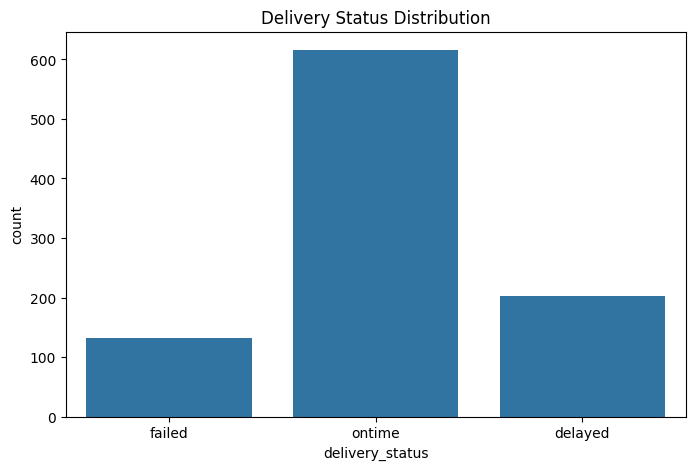

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=deliveries, x="delivery_status")

plt.title("Delivery Status Distribution")
plt.show()

Interpretation for Delivery Status Chart

Most deliveries were completed successfully, while failed deliveries represented a smaller percentage of operations.

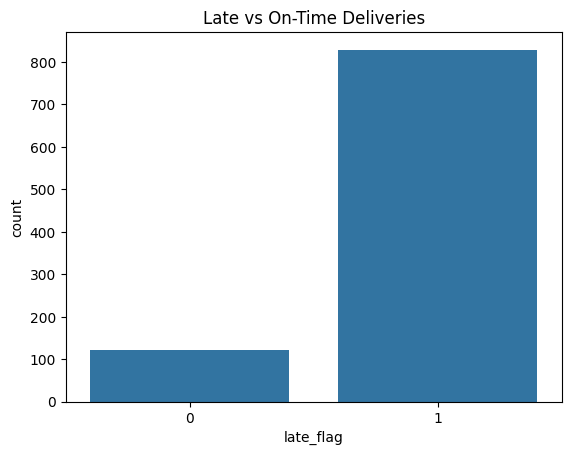

In [24]:
#late deliveries
sns.countplot(data=deliveries, x="late_flag")

plt.title("Late vs On-Time Deliveries")
plt.show()

Interpretation for Late Delivery Chart

The analysis shows that a noticeable proportion of deliveries were late, suggesting possible route-planning or operational inefficiencies.

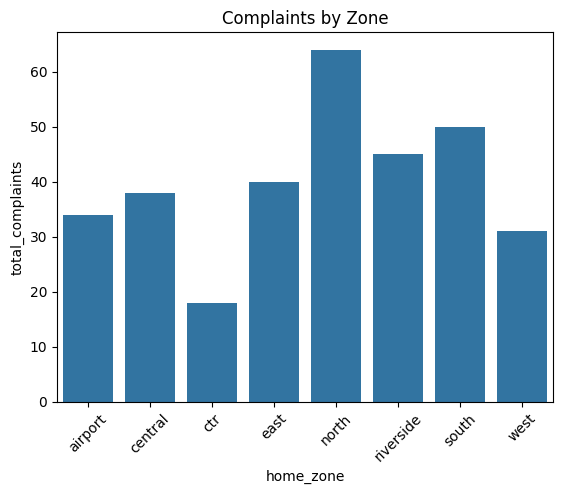

In [25]:
# Complaints by Zone
zone_complaints = customers.groupby("home_zone")["total_complaints"].sum().reset_index()
sns.barplot(
    data=zone_complaints,
    x="home_zone",
    y="total_complaints"
)
plt.xticks(rotation=45)
plt.title("Complaints by Zone")
plt.show()


Interpretation for Complaints by Zone

Some zones generated significantly more complaints than others, indicating potential service quality issues in specific regions.